In [9]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [10]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------

store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Nitish"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [7]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [3]:
# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatOpenAI(model="gpt-4o-mini")

In [11]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]
    
    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)
    
    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = "" # prompt says it may be empty
    
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_details_content)
    
    system_msg = SystemMessage(content=system_prompt)
    
    response = llm.invoke([system_msg] + state["messages"]) # Adding LTM content to Context of the llm
    return {"messages": [response]}

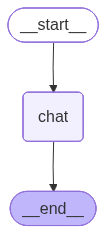

In [12]:
# Build the Graph

builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [14]:
# ----------------------------
# 4) Run it(provide user_id in config)
# ----------------------------

config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/multipart in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/multipart', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')
